In [1]:
cd EEG_psychostimulant

[Errno 2] No such file or directory: 'EEG_psychostimulant'
/home/hamza97/EEG_psychostimulant


/home/hamza97/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
results_dir = "/home/hamza97/projects/def-kjerbi/hamza97/new_Res"

In [ ]:
import sys
sys.path.append("..")
from viz.embeddings import load_embeddings
embeddings_array, subjetcs_array, time_segments_array = load_embeddings(253, 10)

 47%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                                                                                          | 120/253 [00:21<00:11, 11.37it/s]

Embeddings file not found for subject 119


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 253/253 [00:48<00:00,  5.18it/s]


Embeddings file not found for subject 253


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [00:00<00:00, 56947.59it/s]


In [2]:
embeddings_array.shape, subjetcs_array.shape, time_segments_array.shape

((25162, 19, 11, 512), (25162,), (25162,))

In [3]:
from viz.embeddings import reshape_embeddings
embeddings_array = reshape_embeddings(embeddings_array)

In [4]:
embeddings_array.shape

(25162, 107008)

In [5]:
import numpy as np
np.isnan(embeddings_array).any()

np.False_

In [6]:
nan_idx = np.where(np.isnan(embeddings_array))
print("NaN values found at indices:", nan_idx)
print("Cleaning data...")


NaN values found at indices: (array([], dtype=int64), array([], dtype=int64))
Cleaning data...


In [7]:
np.unique(nan_idx[0])

array([], dtype=int64)

In [8]:
subjetcs_array[np.unique(nan_idx[0])]

array([], dtype=int64)

In [9]:
from umap import UMAP
umap = UMAP(n_components=2)
trans = umap.fit(X=embeddings_array, n_jobs = -1)

/home/hamza97/venv_eeg_psychostim/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [10]:
last_patient_point = int(np.where(subjetcs_array == 126)[0][-1])+1
last_patient_point

12591

In [ ]:
patient_embeddings = trans.transform(embeddings_array[:last_patient_point, :])
control_embeddings = trans.transform(embeddings_array[last_patient_point:, :])


/home/hamza97/venv_eeg_psychostim/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [9]:
import os
embeddings_dir = "/home/hamza97/projects/def-kjerbi/hamza97/new_Res"
np.save(os.path.join(embeddings_dir, "patient_only_embeddings_10ms.npy"), patient_embeddings)
np.save(os.path.join(embeddings_dir, "control_embeddings_10ms.npy"), control_embeddings)
np.save(os.path.join(embeddings_dir, "subjetcs_array_10ms.npy"), subjetcs_array)
np.save(os.path.join(embeddings_dir, "time_segments_array_10ms.npy"), time_segments_array)


In [6]:
import os
# load embeddings
embeddings_dir = "/home/hamza97/projects/def-kjerbi/hamza97/new_Res"

patient_embeddings = np.load(os.path.join(embeddings_dir, "patient_only_embeddings_10ms.npy"))
control_embeddings = np.load(os.path.join(embeddings_dir, "control_embeddings_10ms.npy"))
all_subjects = np.load(os.path.join(embeddings_dir, "subjetcs_array_10ms.npy"))

In [7]:
# Plot avgd embeddings
def avg_embeddings(subjects, embeddings):
    avg_embeddings = []
    for subject in np.unique(subjects):
        avg_embedding = np.mean(embeddings[subjects == subject], axis=0)
        avg_embeddings.append(avg_embedding)
    avg_embeddings = np.array(avg_embeddings)
    return avg_embeddings

In [13]:
patient_embeddings_avg = avg_embeddings(subjetcs_array[:last_patient_point], patient_embeddings)
control_embeddings_avg = avg_embeddings(subjetcs_array[last_patient_point:], control_embeddings)

In [9]:
# 1. Age groups: 1 for ages 5-12, 2 for ages 13-18
group_mapping = {"PAT": 'Patient', "CTR": 'Control'}

age_groups_mapping = {1: '5-12', 2: '13-18'}

# 2. Psychostimulant category:
# 0 for conrtols (no psychostimulant), 1 for lisdexamfetamine, 2 for methylphenidate, 3 for other psychostimulants 
# 'Lisdexamfetamine, Methylphenidate': int(3), 'Amphetamine/dextroamphetamine salt (Adderall)': int(4), 'Dextroamphetamine (Dexedrine)': int(5)}
psychostimulant_mapping = {
    0: 'Control',
    1: 'Lisdexamfetamine',
    2: 'Methylphenidate',
    3: 'Lisdexamfetamine & Methylphenidate',
    4: 'Adderall',
    5: 'Dexedrine'
}

# 3. TDAH: 0 for control, 1 for patients with TDAH, 2 for patients without TDAH
tdah_mapping = {0: 'Control', 1: 'Patient TDAH', 2: 'Patient Non-TDAH'}

# 4. TSA: 0 for control, 1 for patients with TSA, 2 for patients without TSA,
#    and 3 for potential TSA
tsa_mapping = {0: 'Control', 1: 'Patient TSA', 2: 'Patient Non-TSA', 3: 'Patient Potential TSA'}

# 5. Epilepsy: 0 for control, 1 for patients with Epilepsy, 2 for patients without,
#    and 3 for potential epilepsy
epilepsy_mapping = {0: 'Control', 1: 'Patient Epilepsy', 2: 'Patient Non-Epilepsy', 3: 'Patient Potential Epilepsy'}

# 6. TDAH and TSA:
# 0: Control, 1: Both TDAH and TSA, 2: TDAH only, 3: TSA only, 4: Neither
tdah_tsa_mapping = {0: 'Control', 1: 'Patient TDAH and TSA', 2: 'Patient TDAH only', 3: 'Patient TSA only', 4: 'Patient Neither'}

# 7. TDAH and Epilepsy:
# 0: Control, 1: Both TDAH and Epilepsy, 2: TDAH only, 3: Epilepsy only, 4: Neither
tdah_epi_mapping = {0: 'Control', 1: 'Patient TDAH and Epilepsy', 2: 'Patient TDAH only', 3: 'Patient Epilepsy only', 4: 'Patient Neither'}

# 8. TSA and Epilepsy:
# 0: Control, 1: Both TSA and Epilepsy, 2: TSA only, 3: Epilepsy only, 4: Neither
tsa_epi_mapping = {0: 'Control', 1: 'Patient TSA and Epilepsy', 2: 'Patient TSA only', 3: 'Patient Epilepsy only', 4: 'Patient Neither'}

# 9. TDAH, TSA and Epilepsy:
# 0: Control, 1: All three, 2: TDAH & TSA only, 3: TDAH & Epilepsy only, 
# 4: TSA & Epilepsy only, 5: TDAH only, 6: TSA only, 7: Epilepsy only, 8: None
tdah_tsa_epi_mapping = {
    0: 'Control',
    1: 'Patient TDAH, TSA & Epilepsy',
    2: 'Patient TDAH & TSA only',
    3: 'Patient TDAH & Epilepsy only',
    4: 'Patient TSA & Epilepsy only',
    5: 'Patient TDAH only',
    6: 'Patient TSA only',
    7: 'Patient Epilepsy only',
    8: 'Patient None'
}

In [10]:
import pandas as pd
df = pd.read_csv("/home/hamza97/projects/rrg-shahabkb/hamza97/data/csv/subjects_with_groups.csv")

In [14]:
df_embeddings_patients = pd.DataFrame(patient_embeddings_avg, columns=["embedding_1", "embedding_2"])
df_embeddings_control = pd.DataFrame(control_embeddings_avg, columns=["embedding_1", "embedding_2"])
df_embeddings = pd.concat([df_embeddings_patients, df_embeddings_control], ignore_index=True)
df_embeddings["subject"] = np.unique(subjetcs_array)
df_new = pd.merge(df_embeddings, df, on="subject", how="inner")

In [15]:
df_new.columns

Index(['embedding_1', 'embedding_2', 'subject', 'group',
       'psychostimulant_description', 'psychostimulant_category', 'TDAH',
       'TSA', 'Epilepsy', 'Age', 'Sex', 'Psychostimulant (y/n)', 'age_groups',
       'TDAH_TSA', 'TDAH_Epilepsy', 'TSA_Epilepsy', 'TDAH_TSA_Epilepsy'],
      dtype='object')

In [16]:
colors = ["#28CEFF", "#FE4463", "#9C7772", "#2645B9", "#3BB081", "#FFB854", "#A0A19E", "#FFA0A0", "#A0A0FF", "#A0FFA0",]

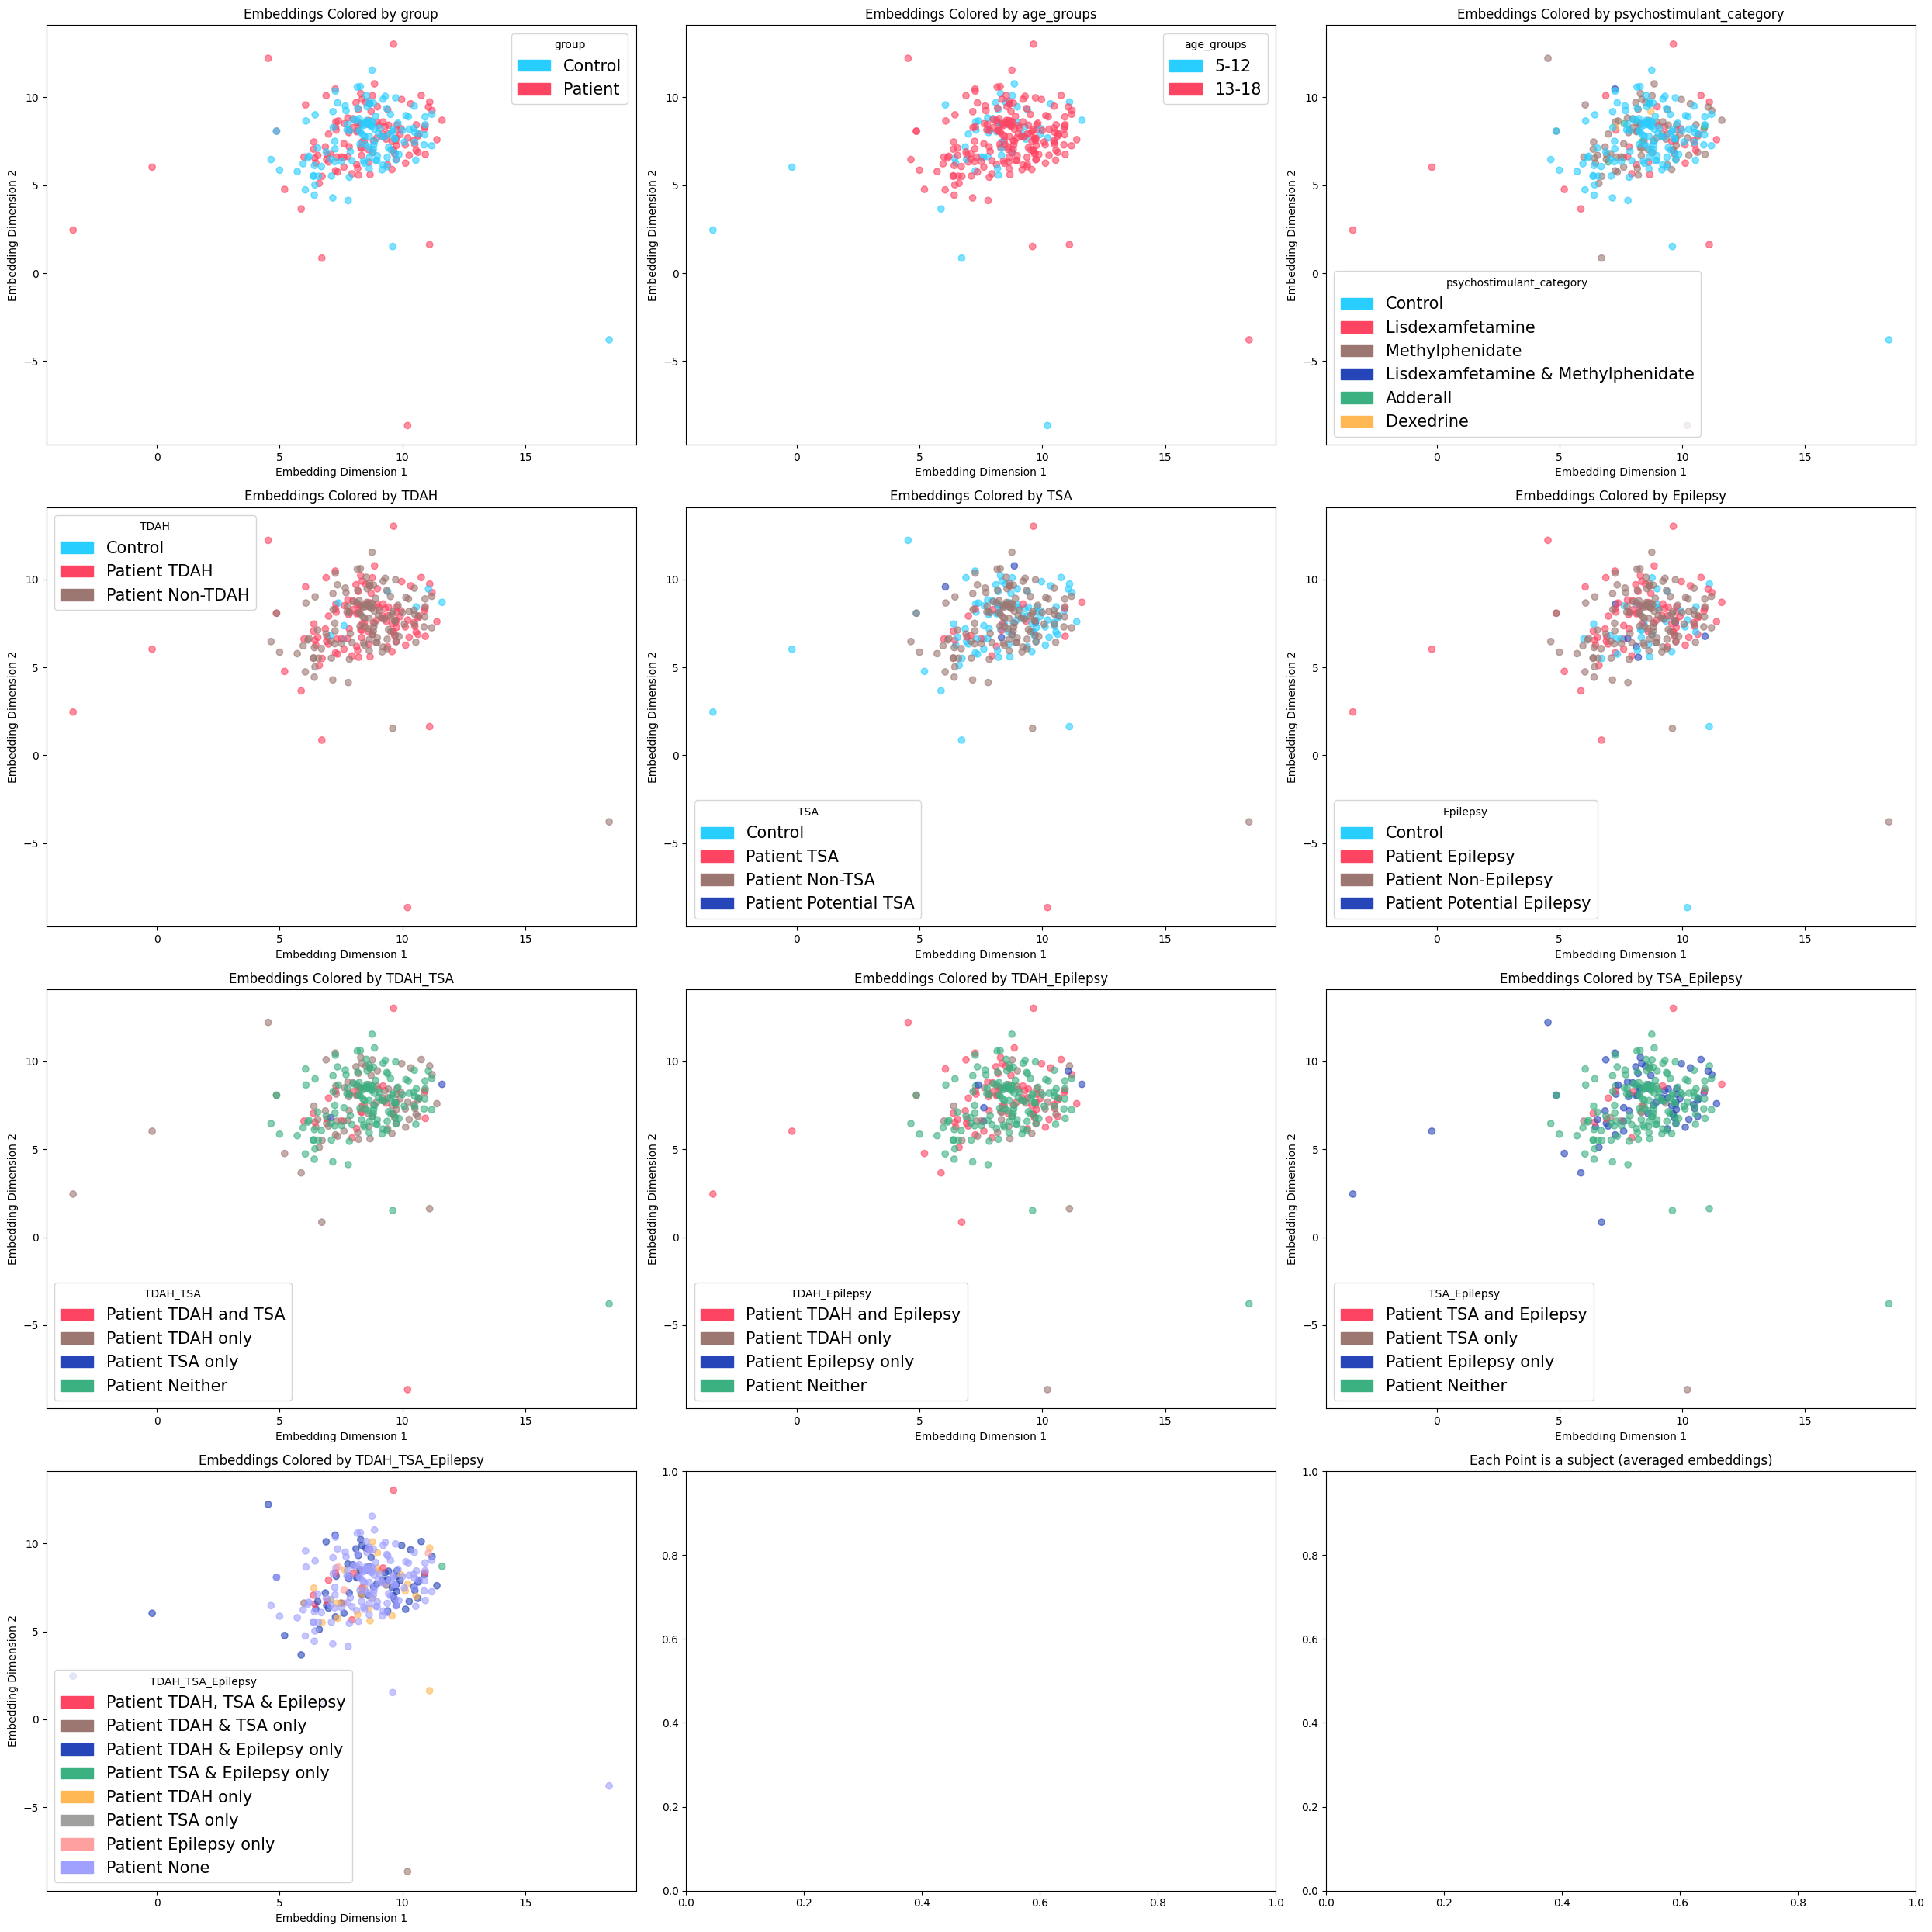

In [17]:
import pandas as pd

import matplotlib.patches as mpatches
columns = ["group", "age_groups", "psychostimulant_category", "TDAH", "TSA", "Epilepsy", "TDAH_TSA", "TDAH_Epilepsy", "TSA_Epilepsy", "TDAH_TSA_Epilepsy"]
mapping_dicts = [group_mapping, age_groups_mapping, psychostimulant_mapping, tdah_mapping, tsa_mapping, epilepsy_mapping, tdah_tsa_mapping, tdah_epi_mapping, tsa_epi_mapping, tdah_tsa_epi_mapping]

# Create a 3x3 grid to plot all 9 subplots
fig, axes = plt.subplots(4, 3, figsize=(25, 25))
axes = axes.flatten()

for i, (column, mapping) in enumerate(zip(columns, mapping_dicts)):
    # Create a color mapping: sort keys so colors are consistently assigned and assign a color per key
    color_mapping = {k: colors[idx] for idx, k in enumerate(sorted(mapping.keys()))}
    # Map each value in the column to its corresponding color; fill missing mappings with 'grey'
    scatter_colors = df_new[column].map(color_mapping).fillna('grey')
    
    axes[i].scatter(df_new["embedding_1"], df_new["embedding_2"], c=scatter_colors, alpha=0.6)
    axes[i].set_title(f"Embeddings Colored by {column}")
    axes[i].set_xlabel("Embedding Dimension 1")
    axes[i].set_ylabel("Embedding Dimension 2")
    
    # Get unique values (ignoring NaNs) for the legend
    unique_vals = sorted([val for val in df_new[column].unique() if pd.notna(val)])
    handles = [mpatches.Patch(color=color_mapping[val], label=mapping[val]) for val in unique_vals]
    axes[i].legend(handles=handles, title=column, fontsize =15)
plt.title("Each Point is a subject (averaged embeddings)")
plt.tight_layout()
plt.show()


In [18]:
df_embeddings_patients = pd.DataFrame(patient_embeddings, columns=["embedding_1", "embedding_2"])
df_embeddings_control = pd.DataFrame(control_embeddings, columns=["embedding_1", "embedding_2"])
df_embeddings = pd.concat([df_embeddings_patients, df_embeddings_control], ignore_index=True)
df_embeddings["subject"] = subjetcs_array
df_new = pd.merge(df_embeddings, df, on="subject", how="inner")

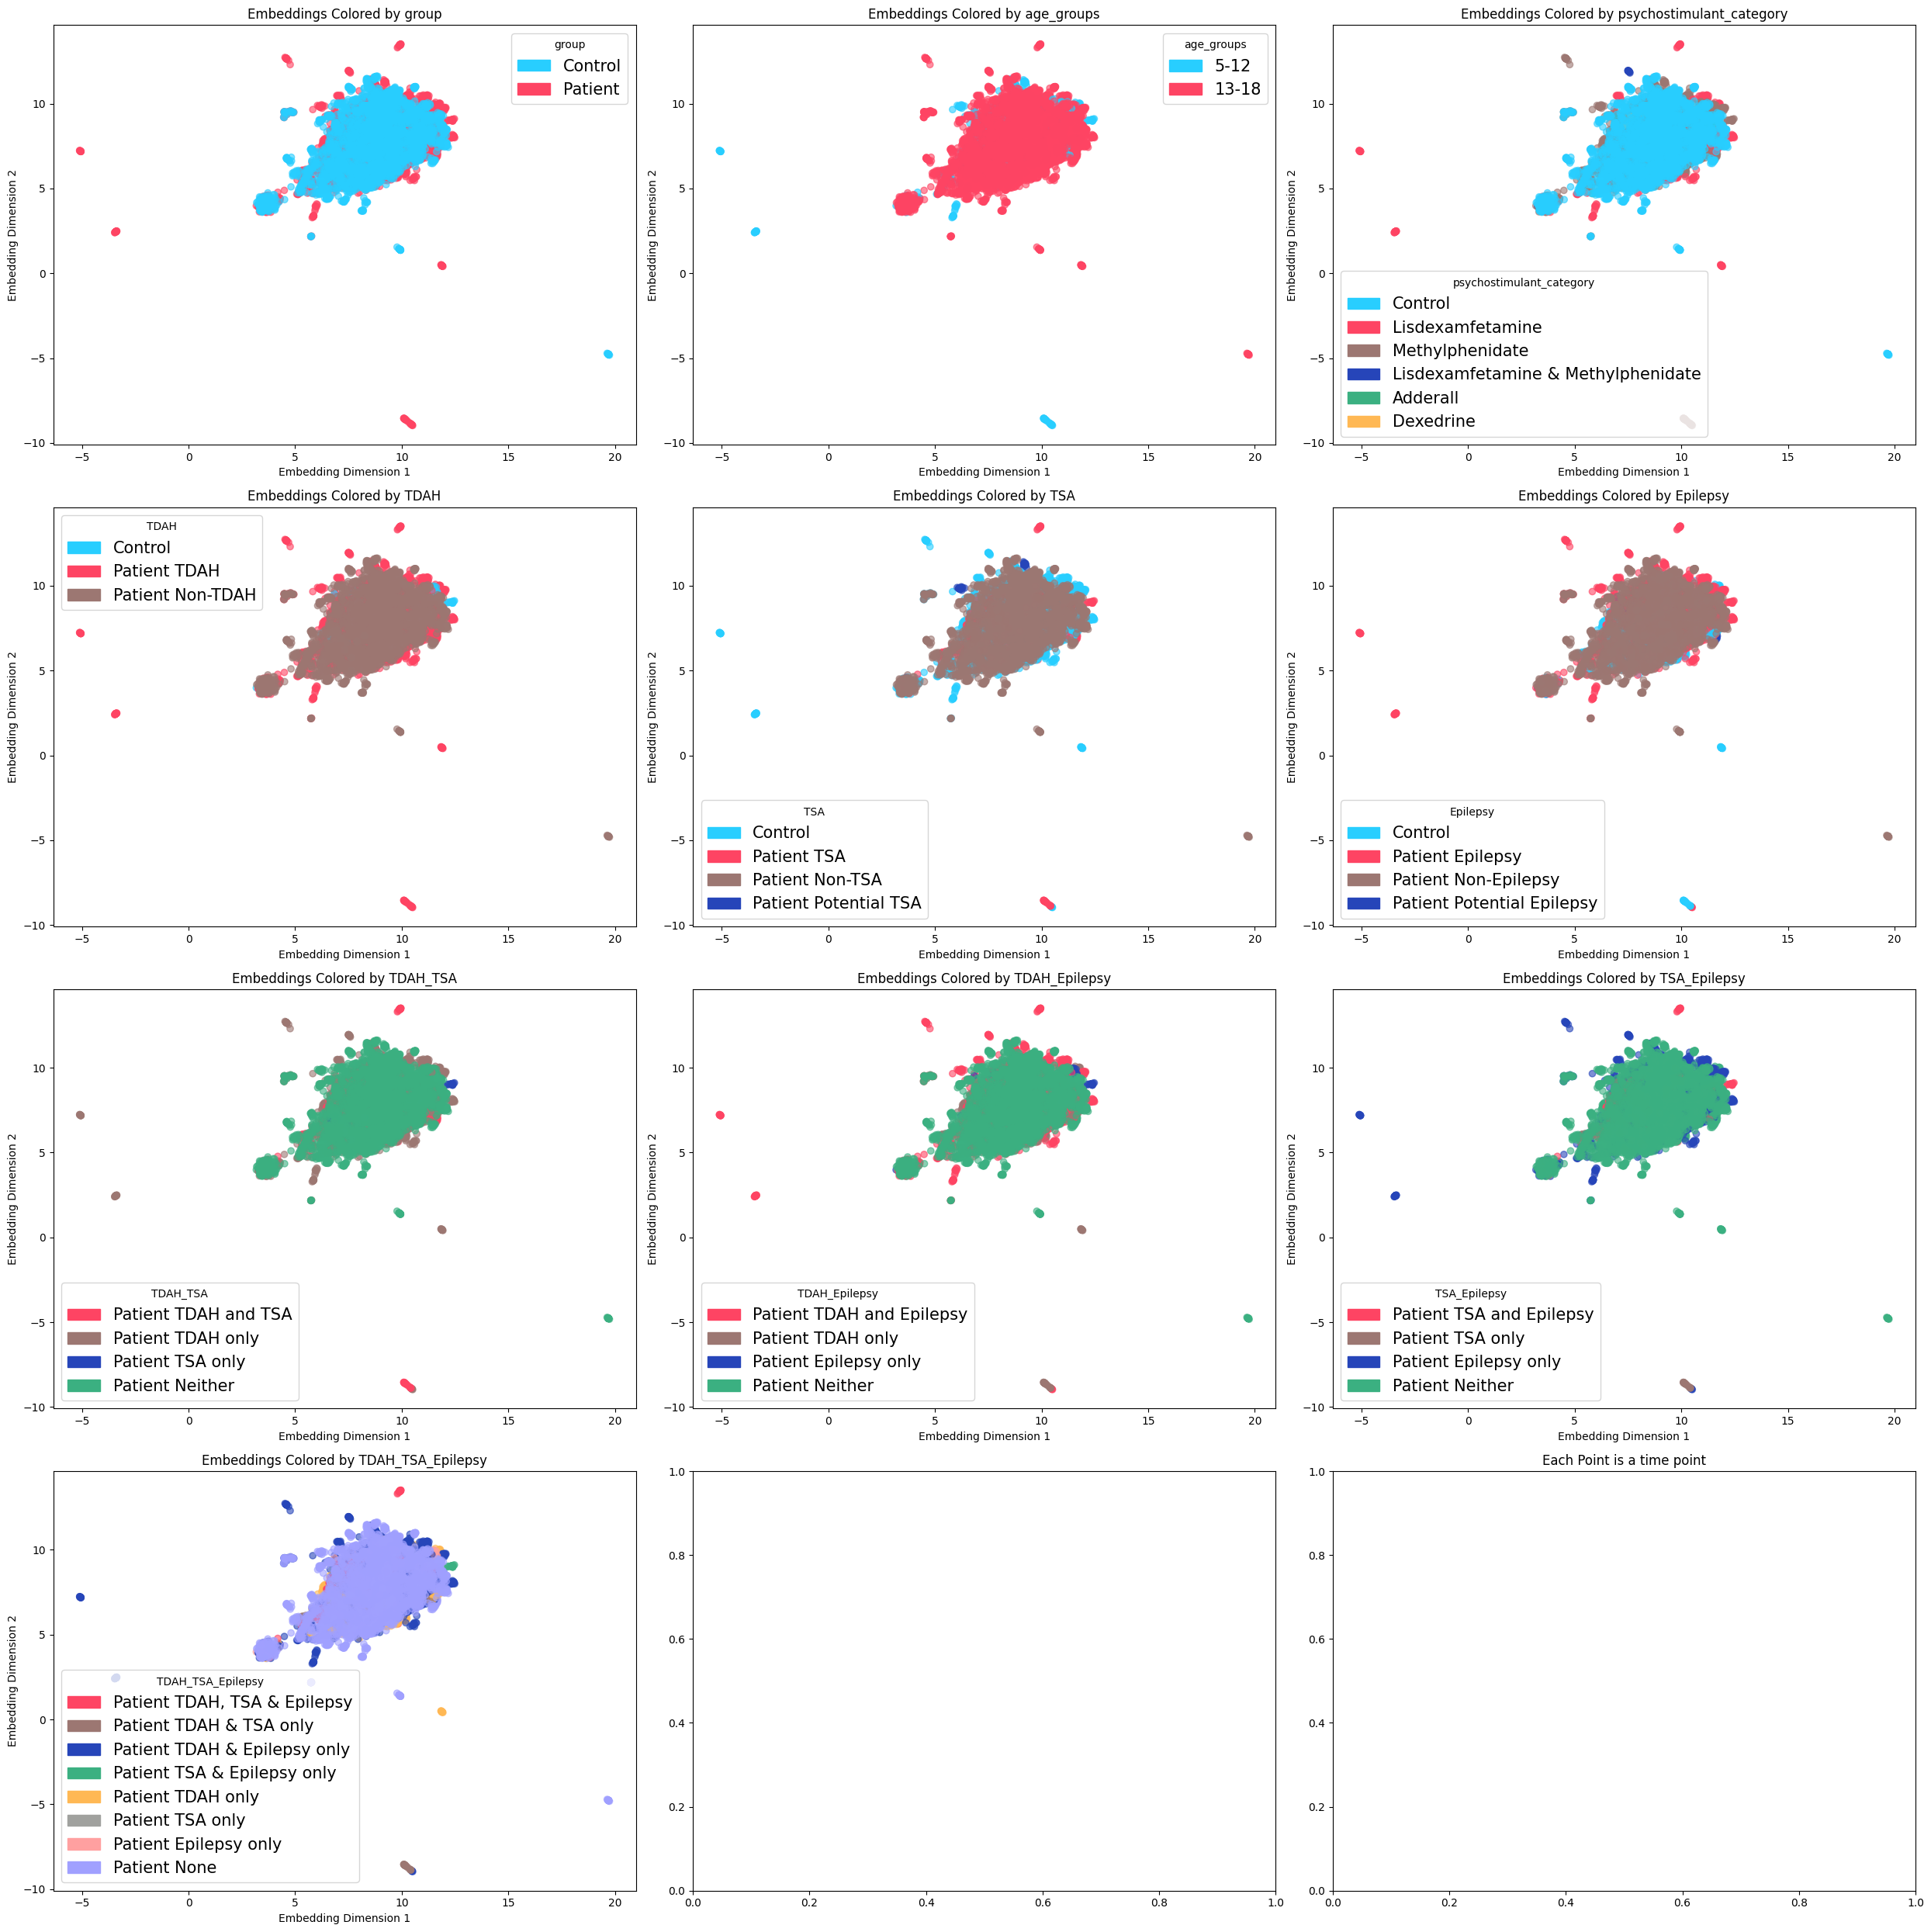

In [19]:
import pandas as pd

import matplotlib.patches as mpatches

# Create a 3x3 grid to plot all 9 subplots
fig, axes = plt.subplots(4, 3, figsize=(25, 25))
axes = axes.flatten()

for i, (column, mapping) in enumerate(zip(columns, mapping_dicts)):
    # Create a color mapping: sort keys so colors are consistently assigned and assign a color per key
    color_mapping = {k: colors[idx] for idx, k in enumerate(sorted(mapping.keys()))}
    # Map each value in the column to its corresponding color; fill missing mappings with 'grey'
    scatter_colors = df_new[column].map(color_mapping).fillna('grey')
    
    axes[i].scatter(df_new["embedding_1"], df_new["embedding_2"], c=scatter_colors, alpha=0.6)
    axes[i].set_title(f"Embeddings Colored by {column}")
    axes[i].set_xlabel("Embedding Dimension 1")
    axes[i].set_ylabel("Embedding Dimension 2")
    
    # Get unique values (ignoring NaNs) for the legend
    unique_vals = sorted([val for val in df_new[column].unique() if pd.notna(val)])
    handles = [mpatches.Patch(color=color_mapping[val], label=mapping[val]) for val in unique_vals]
    axes[i].legend(handles=handles, title=column, fontsize =15)
plt.title("Each Point is a time point")
plt.tight_layout()
plt.show()
